<a href="https://colab.research.google.com/github/redouanelg/climatsuds-tutorials/blob/main/Data_Access/arraylake_era5_access.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install arraylake pcodec

In [ ]:
from arraylake import Client
import xarray as xr
import matplotlib.pyplot as plt

client = Client()
client.login()  # requires free Earthmover account

repo = client.get_repo("earthmover-public/era5")
session = repo.readonly_session(branch="main")
ds = xr.open_zarr(session.store,  group="single/temporal", chunks=None)


In [ ]:
ds

<xarray.Dataset> Size: 110TB
Dimensions:     (valid_time: 753888, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-12-31T23:...
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    lsm         (latitude, longitude) float32 4MB ...
Data variables: (12/35)
    blh         (valid_time, latitude, longitude) float32 3TB ...
    cape        (valid_time, latitude, longitude) float32 3TB ...
    cp          (valid_time, latitude, longitude) float32 3TB ...
    fdir        (valid_time, latitude, longitude) float32 3TB ...
    fg10        (valid_time, latitude, longitude) float32 3TB ...
    d2m         (valid_time, latitude, longitude) float32 3TB ...
    ...          ...
    tsr         (valid_time, latitude, longitude) float32 3TB ...
    u10         (valid_time, latitude, longitude) float32 3TB ...
    u100        (valid_time, latitude, longitude) float32 3TB ...
    v10         (valid_time, latitude, longitude) float32 3TB ...
    zust        (valid_time, latitude, longitude) float32 3TB ...
    v100        (valid_time, latitude, longitude) float32 3TB ...
Attributes: (12/46)
    Conventions:                CF-1.7
    title:                      ERA5 Hourly Global Reanalysis - chunked for t...
    summary:                    ERA5 is the fifth generation ECMWF atmospheri...
    keywords:                   ERA5, reanalysis, atmosphere, climate, ECMWF,...
    keywords_vocabulary:        GCMD Science Keywords
    id:                         era5
    ...                         ...
    proj:code:                  EPSG:4326
    proj:epsg:                  4326
    GRIB_centre:                ecmf
    GRIB_centreDescription:     European Centre for Medium-Range Weather Fore...
    GRIB_subCentre:             0
    history:                    2026-05-10T20:01 GRIB to CDM+CF via cfgrib-0....

In [ ]:
# pull a timeseries
ts = ds.t2m.sel(longitude=106, latitude=4, valid_time=slice("2000", "2025")).load()
ts

<xarray.DataArray 't2m' (valid_time: 227928)> Size: 912kB
array([297.8272 , 298.03644, 298.31567, ..., 299.1545 , 299.04553,
       299.00607], dtype=float32)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 2MB 2000-01-01 ... 2025-12-31T23:...
    longitude   float64 8B 106.0
    latitude    float64 8B 4.0
    lsm         float32 4B nan
Attributes: (12/32)
    GRIB_paramId:                             167
    GRIB_dataType:                            an
    GRIB_numberOfPoints:                      1038240
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               K
    long_name:                                2 metre temperature
    units:                                    K
    standard_name:                            unknown
    GRIB_surface:                             0.0

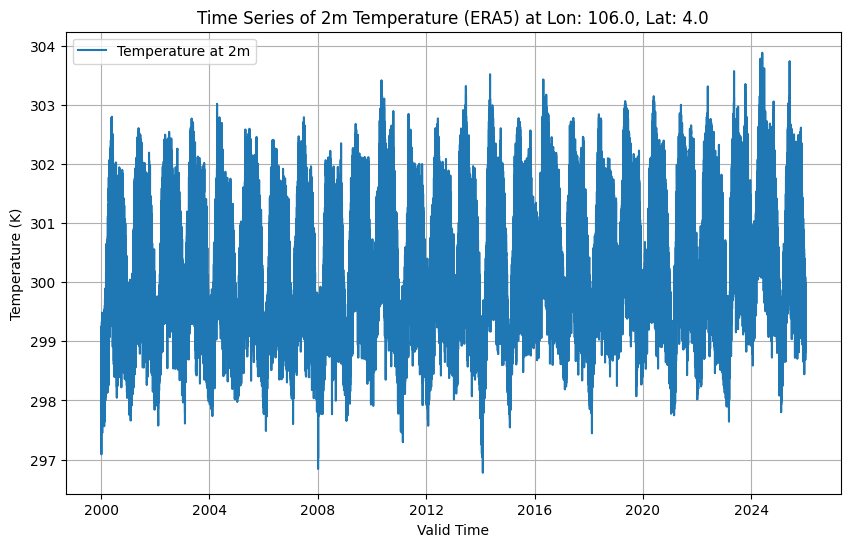

In [ ]:
plt.figure(figsize=(10, 6))
ts.plot(label='Temperature at 2m')
# Extract longitude and latitude from the xarray DataArray 'ts'
lon = ts.longitude.item() if hasattr(ts.longitude, 'item') else ts.longitude
lat = ts.latitude.item() if hasattr(ts.latitude, 'item') else ts.latitude
plt.title(f'Time Series of 2m Temperature (ERA5) at Lon: {lon}, Lat: {lat}')
plt.xlabel('Valid Time')
plt.ylabel('Temperature (K)')
plt.grid(True)
plt.legend()
plt.show()